In [2]:
import tifffile as tf
import matplotlib.pyplot as plt
import numpy as np
import tomopy
from tomobar.methodsIR import RecToolsIR
from spectro_tomography import *

data_size = 4096, rec_size = 16384


  0%|          | 0/100 [00:00<?, ?it/s]

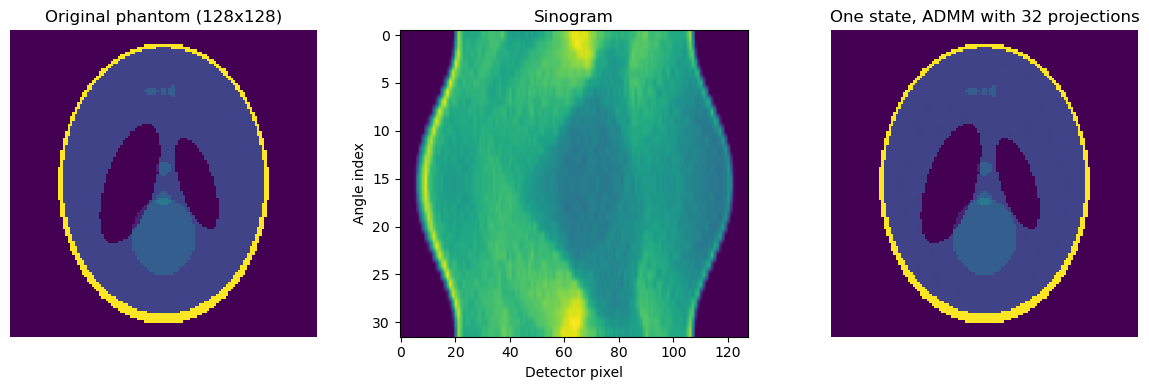

In [13]:
# single-state tomography with ADMM

# load a test image as object 
# V = tf.imread('barbara_128.tif')/255.0


V = shepp_logan(128)
obj_row, obj_col = np.shape(V) 

num_angles = int(obj_col*1.5/6) # obj_col*1.5 is Crowther criterion 

# det_size is set to be larger to avoid corner effect for some samples 
det_size = int(obj_col*1.0)

used_spect = np.ones((30,1)) # single state, regular tomography

mse_list = []

# generate the list of angle-energy pairs and the codebook 
# that records the relative intensity change of each state based on reference spectra
# 'uniform-random' refers to uniform angular step and random energy selection
# other options used in the paper are 'uniform-interlaced', 'uniform-segmented', and 'uniform-interlaced-random'
# the last option is for interlaced sampling with randomized spectra 


angle, codebook, ind = generate_plan(used_spect,[0,np.pi],num_angles,'uniform-random')
# angle = np.linspace(0,np.pi,num_angle)


sino = []
for i in range (len(angle)):
    proj_geom = astra.create_proj_geom('parallel',1.0,det_size,angle[i])
    vol_geom = astra.create_vol_geom(obj_row,obj_col)
    proj_id = astra.create_projector('linear',proj_geom,vol_geom)
    [sigogram_id, sinogram] = astra.create_sino(V,proj_id)
    sino.append(sinogram)
sino = np.squeeze(np.array(sino))
maxVal = sino.max()

# add Poisson noise and scale back to the original intensity range
# sino_noise=np.random.poisson(np.array(sino*200/maxVal,dtype='int'))*maxVal/200

for i in range(1): # repeat the calculation with different randomized spectra for statistics
    # use random initialization
    x_init = []
    x_init.append(np.random.rand(obj_row,obj_col))
#     x_init.append(np.random.rand(obj_row,obj_col))
#     x_init.append(np.random.rand(obj_row,obj_col))
    
    rec,err = multistate_tomo_joint_TV(sino,angle,0,\
                                       [obj_row,obj_col],codebook,\
                                       0.1,1,100,x0=None,seq_save=True,method='gmres')
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(V,clim=[0,1],interpolation='none')
plt.title(f"Original phantom ({obj_row}x{obj_col})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sino, aspect="auto")
plt.title("Sinogram")
plt.xlabel("Detector pixel")
plt.ylabel("Angle index")

plt.subplot(1, 3, 3)
plt.imshow(np.squeeze(rec[-1]),clim=[0,1],interpolation='none')
plt.title(f"One state, ADMM with {num_angles} projections")
plt.axis("off")

plt.tight_layout()
plt.show()

number of projections = 32


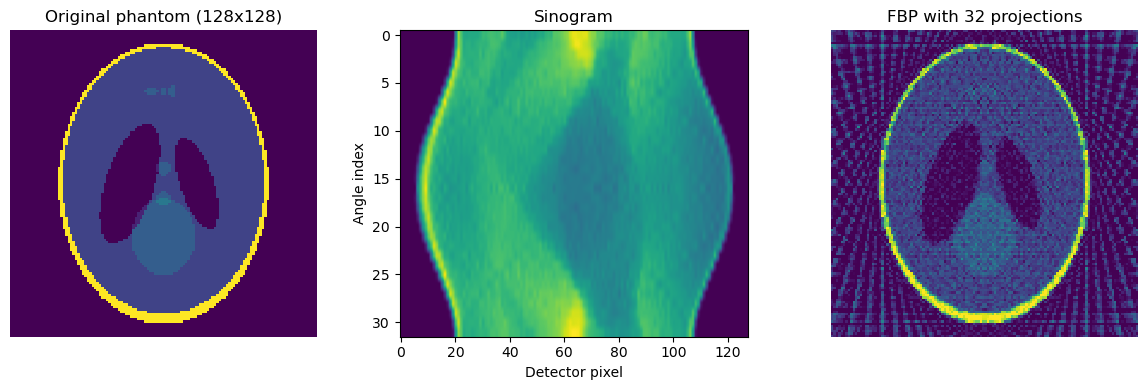

In [11]:
# single-stae tomography with FBP

import numpy as np
import matplotlib.pyplot as plt
import astra
from skimage.data import shepp_logan_phantom
from skimage.transform import resize

# define FBP reconstruction function using Astra   

def astra_fbp_reconstruction(
    sinogram,
    angles,
    image_size,
    detector_spacing=1.0,
    use_gpu=False,
    filter_type="Ram-Lak",
):
    sinogram = np.asarray(sinogram, dtype=np.float32)
    angles = np.asarray(angles, dtype=np.float32)

    num_angles, num_detectors = sinogram.shape

    vol_geom = astra.create_vol_geom(image_size, image_size)

    proj_geom = astra.create_proj_geom(
        "parallel",
        detector_spacing,
        num_detectors,
        angles,
    )

    sino_id = astra.data2d.create("-sino", proj_geom, sinogram)
    rec_id = astra.data2d.create("-vol", vol_geom)

    projector_id = None

    if use_gpu:
        cfg = astra.astra_dict("FBP_CUDA")
        cfg["ProjectionDataId"] = sino_id
        cfg["ReconstructionDataId"] = rec_id
        cfg["option"] = {
            "FilterType": filter_type
        }
    else:
        projector_id = astra.create_projector("linear", proj_geom, vol_geom)

        cfg = astra.astra_dict("FBP")
        cfg["ProjectorId"] = projector_id
        cfg["ProjectionDataId"] = sino_id
        cfg["ReconstructionDataId"] = rec_id
        cfg["option"] = {
            "FilterType": filter_type
        }

    alg_id = astra.algorithm.create(cfg)

    try:
        astra.algorithm.run(alg_id)
        reconstruction = astra.data2d.get(rec_id)
    finally:
        astra.algorithm.delete(alg_id)
        astra.data2d.delete(sino_id)
        astra.data2d.delete(rec_id)

        if projector_id is not None:
            astra.projector.delete(projector_id)

    return reconstruction


# set up parameters and load image

image_size = 128
num_angles = int(image_size*1.5/6.0)
print(f"number of projections = {num_angles}")
det_size = int(image_size*1.0) # detector size can be set larger to avoid edge effect seen in FBP

angles = np.linspace(0, np.pi, num_angles, endpoint=False).astype(np.float32)

vol_geom = astra.create_vol_geom(image_size, image_size)

phantom = shepp_logan(128)
# phantom = tf.imread('barbara_128.tif')/255.0

phantom_id = astra.data2d.create("-vol", vol_geom, phantom)

proj_geom = astra.create_proj_geom(
    "parallel",
    1.0,
    det_size,
    angles,
)

projector_id = astra.create_projector("linear", proj_geom, vol_geom)

# Forward projection: create sinogram
sinogram_id, sinogram = astra.create_sino(phantom, projector_id)

# Reconstruct
reconstruction = astra_fbp_reconstruction(
    sinogram=sinogram,
    angles=angles,
    image_size=det_size,
    detector_spacing=1.0,
    use_gpu=False,       # change to False if GPU fails
    filter_type="Ram-Lak",
)

# Clean up forward-projection objects
astra.data2d.delete(phantom_id)
astra.data2d.delete(sinogram_id)
astra.projector.delete(projector_id)

# Display

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(phantom,clim=[0,1],interpolation='none')
plt.title(f"Original phantom ({image_size}x{image_size})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sinogram, aspect="auto")
plt.title("Sinogram")
plt.xlabel("Detector pixel")
plt.ylabel("Angle index")

plt.subplot(1, 3, 3)
plt.imshow(reconstruction,clim=[0,1],interpolation='none')
plt.title(f"FBP with {num_angles} projections")
plt.axis("off")

plt.tight_layout()
plt.show()
    
    
